# 05 — Model comparison, business metrics, limitations and deployment

In [1]:
from pathlib import Path
import os
import sys

CURRENT = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (CURRENT, *CURRENT.parents) if (path / "src").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Project root табылмады. Notebook-ты project папкасының ішінен ашыңыз."
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Python:", sys.executable)


PROJECT_ROOT: C:\Users\Ansagan\Downloads\smart_vision_final_project_laptop_cpu
Python: c:\Users\Ansagan\venvs\ml-yolo-cpu\Scripts\python.exe


In [2]:
import matplotlib.pyplot as plt
from IPython.display import display

from src.compare_models import load_model_comparison
from src.config import METRICS_DIR

comparison_df = load_model_comparison(METRICS_DIR)
if comparison_df.empty:
    raise FileNotFoundError(
        "Метрика JSON файлдары жоқ. Алдымен 02, 03 және 04 notebook-тарын орындаңыз."
    )
display(comparison_df)
comparison_df.to_csv(METRICS_DIR / "model_comparison.csv", index=False)


,model,task,dataset,class_count,accuracy,f1_macro,precision,recall,map50,map50_95,inference_ms,fps,model_size_mb,best_params
0,HOG + SVM,object crop classification,C:\Users\Ansagan\Downloads\smart_vision_final_...,20.0,0.945274,0.946509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{'svc__C': 0.01}
1,YOLOv5,object detection,C:\Users\Ansagan\Downloads\smart_vision_final_...,NaN,NaN,NaN,0.976000,0.970000,0.990000,0.874000,NaN,NaN,40.301,
2,YOLOv10,object detection,C:\Users\Ansagan\Downloads\smart_vision_final_...,20.0,NaN,NaN,0.980921,0.984995,0.992092,0.940946,6600.167752,0.151511,61.206,


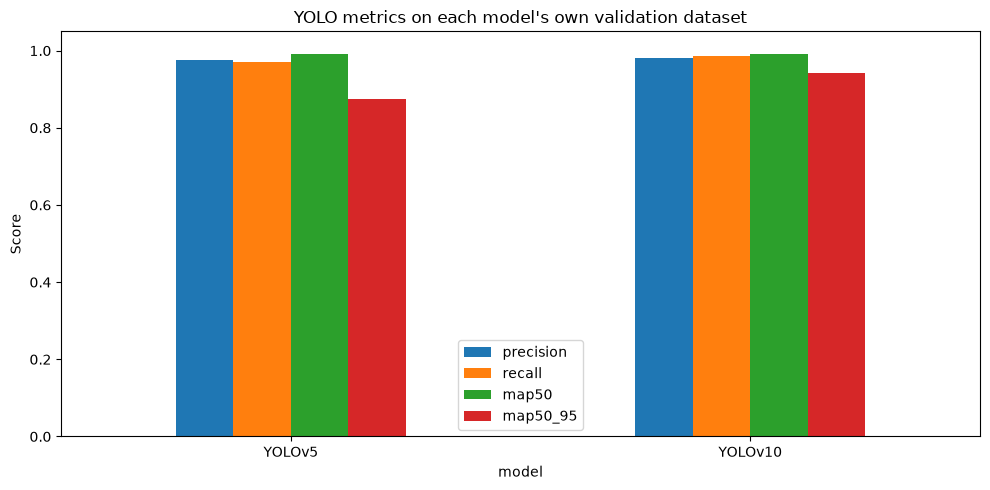

In [3]:
detectors = comparison_df[comparison_df["model"].isin(["YOLOv5", "YOLOv10"])].copy()
metric_table = detectors.set_index("model")[["precision", "recall", "map50", "map50_95"]].dropna(axis=1, how="all")
if not metric_table.empty:
    metric_table.plot(kind="bar", figsize=(10, 5))
    plt.title("YOLO metrics on each model's own validation dataset")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


## Салыстыруды дұрыс түсіндіру

- **YOLOv5** бастапқы, көлемі кіші dataset-те оқытылған.
- **YOLOv10** кеңейтілген, сурет және класс саны көбірек dataset-те оқытылған.
- Сондықтан екі модельдің mAP көрсеткіштері **өз validation dataset-терінде** алынған; бұл таза архитектуралық benchmark емес.
- **HOG + SVM** object-crop classification орындайды, ал YOLO модельдері object detection орындайды. Accuracy/F1 мен mAP тікелей бір метрика ретінде салыстырылмайды.


## Бизнес және ML метрикаларының байланысы

- **Recall жоғарыласа** — жолдағы қауіпті объектіні өткізіп алу ықтималдығы азаяды.
- **Precision жоғарыласа** — жалған ескерту саны азаяды және жүргізушінің жүйеге сенімі артады.
- **mAP50-95** — әртүрлі өлшемдегі объектілерді локализациялау тұрақтылығын көрсетеді.
- **Inference latency/FPS** — нақты уақыттағы ескерту жылдамдығын анықтайды. Мақсат: кемінде 20–30 FPS немесе бір кадрға 33–50 мс.
- **Модель көлемі** — edge-құрылғыға орналастыру құнын және жад талабын анықтайды.

Ұсынылатын бизнес KPI:
1. Қауіпті объектілерді өткізіп алу үлесін азайту.
2. 100 км жолға шаққандағы жалған ескерту санын азайту.
3. Ескерту кідірісін 200 мс-тан төмен ұстау.
4. Түнгі және күндізгі жағдайларда бөлек recall өлшеу.


## Сыни шектеулер

1. Екі YOLO моделі әртүрлі dataset пен класс жиынында оқытылған.
2. Сирек кластардағы class imbalance сапаны төмендетуі мүмкін.
3. Түн, жаңбыр, тұман, қарсы жарық және motion blur жағдайлары бөлек тексерілуі керек.
4. HOG + SVM толық детектор емес; ол дайын bounding-box crop-тарын классификациялайды.
5. Validation dataset нақты өндірістік жол жағдайларын толық қамтымауы мүмкін.
6. Камера бұрышы, resolution және domain shift нәтижеге әсер етеді.


## Deployment стратегиясы

**1-кезең — Desktop demo**
- Python + OpenCV + Ultralytics.
- Сурет, видео және webcam inference.

**2-кезең — Export және оптимизация**
- YOLO моделін ONNX немесе TensorRT форматына export.
- FP16 inference және batch=1 latency benchmark.

**3-кезең — Edge deployment**
- NVIDIA GPU/Jetson: TensorRT.
- Raspberry Pi: жеңіл модель немесе сыртқы accelerator.
- Model monitoring: FPS, confidence, class distribution, false alerts.

**4-кезең — Өндірістік мониторинг**
- Төмен confidence кадрларын сақтау.
- Жаңа деректермен периодты қайта оқыту.
- Dataset/model versioning және rollback.
